#Método de Newton-Raphson


--------------------------------------------------
Iniciando Newton-Raphson: Inciso A
--------------------------------------------------
Iteracion 1: Raíz calculada = 1.454545 | Error = 100.000000
Iteracion 2: Raíz calculada = 1.368900 | Error = 0.062565
Iteracion 3: Raíz calculada = 1.365237 | Error = 0.002684
Iteracion 4: Raíz calculada = 1.365230 | Error = 0.000005

--> RAÍZ FINAL APROXIMADA PARA Inciso A: 1.365230


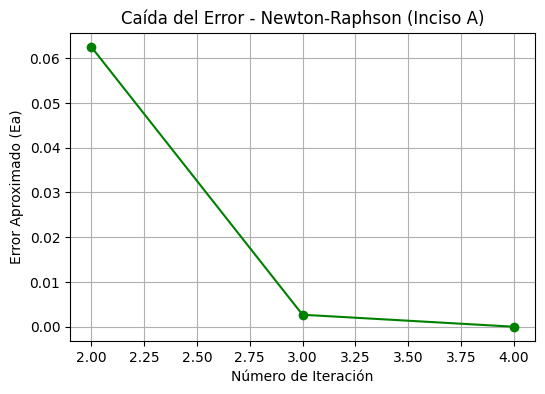


--------------------------------------------------
Iniciando Newton-Raphson: Inciso B
--------------------------------------------------
Iteracion 1: Raíz calculada = 1.000000 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.733049 | Error = 0.364164
Iteracion 3: Raíz calculada = 0.547580 | Error = 0.338709
Iteracion 4: Raíz calculada = 0.472179 | Error = 0.159687
Iteracion 5: Raíz calculada = 0.462249 | Error = 0.021482
Iteracion 6: Raíz calculada = 0.462098 | Error = 0.000326

--> RAÍZ FINAL APROXIMADA PARA Inciso B: 0.462098


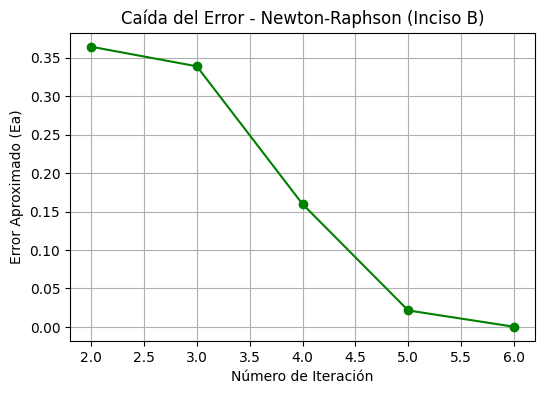


--------------------------------------------------
Iniciando Newton-Raphson: Inciso C
--------------------------------------------------
Iteracion 1: Raíz calculada = 6.780488 | Error = 100.000000
Iteracion 2: Raíz calculada = 6.590088 | Error = 0.028892

--> RAÍZ FINAL APROXIMADA PARA Inciso C: 6.590088


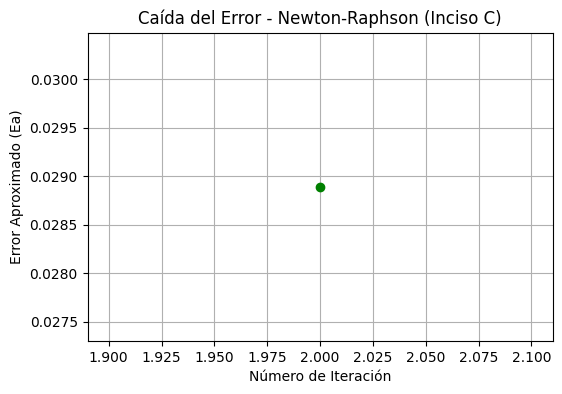


--------------------------------------------------
Iniciando Newton-Raphson: Inciso D
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.800000 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.751869 | Error = 0.064015
Iteracion 3: Raíz calculada = 0.749375 | Error = 0.003329
Iteracion 4: Raíz calculada = 0.749368 | Error = 0.000009

--> RAÍZ FINAL APROXIMADA PARA Inciso D: 0.749368


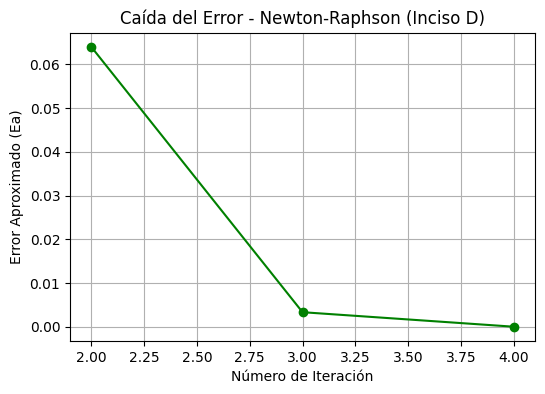

In [10]:
import math
import matplotlib.pyplot as plt

# 1.-Definimos las funciones solicitadas y sus derivadas a mano
def funcion_a(x):
    return (x**3) + 4*(x**2) - 10.0
def derivada_a(x):
    return 3*(x**2) + 8*x

def funcion_b(x):
    return math.exp(3*x) - 4.0
def derivada_b(x):
    return 3 * math.exp(3*x)

def funcion_c(x):
    return -0.4*(x**2) + 2.3*x + 2.2
def derivada_c(x):
    return -0.8*x + 2.3

def funcion_d(x):
    return (x**4) + 3*(x**2) - 2.0
def derivada_d(x):
    return 4*(x**3) + 6*x


# 2.-Método de Newton-Raphson
def ejecutar_newton_raphson(funcion_evaluar, derivada_evaluar, X_Inicial, Error_Esperado, Nombre_Inciso):
    print(f"\n--------------------------------------------------")
    print(f"Iniciando Newton-Raphson: {Nombre_Inciso}")
    print(f"--------------------------------------------------")

    Error_Actual = 100.0  # Valor inicial forzado para entrar al loop
    Punto_Calculado_Pasado = X_Inicial
    Iteracion = 1

    # Listas para guardar la información que irá a las gráficas
    Historial_Iteraciones = []
    Historial_Errores = []

    while Error_Actual > Error_Esperado:
        Funcion_Evaluada = funcion_evaluar(Punto_Calculado_Pasado)
        Derivada_Evaluada = derivada_evaluar(Punto_Calculado_Pasado)

        # Checamos que no nos de cero abajo para no reventar el programa
        if Derivada_Evaluada == 0:
            print("Error: La derivada es cero.")
            break

        # Aplicamos la fórmula de Newton
        Punto_Nuevo = Punto_Calculado_Pasado - (Funcion_Evaluada / Derivada_Evaluada)

        # Comparamos este nuevo punto con el de la iteración pasada (Error Relativo)
        if Iteracion > 1:
            Error_Actual = abs((Punto_Nuevo - Punto_Calculado_Pasado) / Punto_Nuevo)

        # Guardamos datos para la gráfica
        if Iteracion > 1:
            Historial_Iteraciones.append(Iteracion)
            Historial_Errores.append(Error_Actual)

        print(f"Iteracion {Iteracion}: Raíz calculada = {Punto_Nuevo:.6f} | Error = {Error_Actual:.6f}")

        Punto_Calculado_Pasado = Punto_Nuevo
        Iteracion = Iteracion + 1

        # Freno de emergencia por si la función diverge al infinito
        if Iteracion > 100:
            print("Alerta: Se superaron las 100 iteraciones. Abortando ciclo.")
            break

    print(f"\n--> RAÍZ FINAL APROXIMADA PARA {Nombre_Inciso}: {Punto_Nuevo:.6f}")

    # ==========================================
    # 3.-Gráficas

    plt.figure(figsize=(6, 4))
    plt.plot(Historial_Iteraciones, Historial_Errores, marker='o', linestyle='-', color='g')
    plt.title(f"Caída del Error - Newton-Raphson ({Nombre_Inciso})")
    plt.xlabel("Número de Iteración")
    plt.ylabel("Error Aproximado (Ea)")
    plt.grid(True)
    plt.show()


# 4. Ejecución en secuencia de los incisos

# Inciso a) Ea = 0.0001
# Ojo: Usamos 1.0 como arranque porque con 0.0 la derivada da 0.
ejecutar_newton_raphson(funcion_a, derivada_a, 1.0, 0.0001, "Inciso A")

# Inciso b) Ea = 0.01. Arrancamos en 0.
ejecutar_newton_raphson(funcion_b, derivada_b, 0.0, 0.01, "Inciso B")

# Inciso c) Ea = 3% (0.03 decimal). Arrancamos en 0.
ejecutar_newton_raphson(funcion_c, derivada_c, 8.0, 0.03, "Inciso C")

# Inciso d) Ea = 0.0001
# Ojo: Usamos 1.0 como arranque porque con 0.0 la derivada da 0.
ejecutar_newton_raphson(funcion_d, derivada_d, 1.0, 0.0001, "Inciso D")